# Asset Location — a quantitative teardown 🔬
### A full tax-drag household simulator · HAC *t* on 122 overlapping 30-year cohorts · a tax-rate grid · the delta-on-yield regression · the turnover flip · a zero-tax null and a planted-coupon control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Does_it_flip%3F: Confirmed](https://img.shields.io/badge/Does_it_flip%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The asset-location rule (Dammon-Spatt-Zhang 2004) is *arithmetic* — but arithmetic still has to show its number **on the tape**, with uncertainty, under honest frictions. So: a year-by-year household simulator with average-cost basis, loss carryforwards, terminal settlement, one documented decision lag, and Newey-West inference over massively overlapping cohorts.

> ⚠️ **Data note.** Long tape = Shiller monthly price/dividend/GS10 → annual components 1872-2022 (fingerprint `254d1e72f9f7`); modern tape = SPY/IEF unadjusted closes + cash distributions, 2003-2025 (fingerprint `97c3a1b86d4f`). As-of 2026-07-03, complete calendar years only. Index-level data — no survivor panel. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from asset_location import data, strategy as st

HAVE_REAL = data.have_shiller()
HAVE_MODERN = data.have_modern()
if HAVE_REAL:
    SH = data.load_shiller()
    COMP = data.annual_components(SH)
    TAB = st.cohort_table(COMP)
else:
    SH = COMP = TAB = None
print("real Shiller cache:", HAVE_REAL, "| modern SPY/IEF cache:", HAVE_MODERN,
      "| cohorts:", (0 if TAB is None else len(TAB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-03', 'fp_long': '254d1e72f9f7', 'fp_modern': '97c3a1b86d4f', 'long_years': '1872-2022', 'n_years_long': 151, 'n_cohorts': 122, 'horizon': 30, 'hac_lag': 29, 'ordinary': 24, 'ltcg': 15, 'turnover': 10, 'ann_bonds': 6.84, 'ann_stocks': 6.66, 'ann_prorata': 6.76, 'delta_bs': 17.78, 't_bs': 3.55, 'win_bs': 86.9, 'delta_bp': 8.55, 't_bp': 3.11, 'win_bp': 82.8, 'delta_min': -14.46, 'delta_max': 59.14, 'wealth_gap': 5.19, 'trade': (2.67, 2.41, 3.34), 'diff_cost': 0.013, 'quart': [('Q1 (lowest)', 3.06, 12.38, 31), ('Q2', 3.7, 12.53, 30), ('Q3', 4.42, 11.55, 30), ('Q4 (highest)', 7.44, 34.3, 31)], 'slope': 5.57, 't_slope': 67.8, 'grid': [(22, 15, 10.77, 2.26, 77.0), (22, 20, -9.95, -1.84, 31.1), (24, 15, 17.78, 3.55, 86.9), (24, 20, -3.16, -0.57, 46.7), (32, 15, 47.43, 7.68, 100.0), (32, 20, 25.54, 4.09, 91.0), (37, 15, 67.47, 9.62, 100.0), (37, 20, 44.96, 6.56, 100.0)], 'flip': [(0, 26.27, 4.15, 98.4, 17.89), (10, 17.78, 3.55, 86.9, 12.38), (25, 11.32, 2.58, 77.9, 7.31), (50, 5.72, 1.4, 68.9, 2.36), (100, -0.29, -0.07, 53.3, -3.69)], 'modern': {'years': '2003-2025', 'n': 23, 'cpn': 2.9, 'ann_bonds': 7.51, 'ann_stocks': 7.09, 'ann_prorata': 7.31, 'delta_bs': 41.68, 'delta_bp': 19.49, 'sweep': [(0, 53.67), (10, 41.68), (25, 33.54), (50, 27.81), (100, 23.12)]}, 'syn': [('null (zero tax rates)', 0.0, 0.0), ('planted coupon 2%', 15.105, 5.366), ('planted coupon 4%', 21.0, 6.097), ('planted coupon 6%', 29.585, 7.079)]}


real Shiller cache: True | modern SPY/IEF cache: True | cohorts: 122


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` (traditional IRA) | Mean bonds-in-IRA − stocks-in-IRA delta **+17.78 bps/yr** of after-tax annualised return over **122** overlapping 30-year cohorts, **HAC t (lag 29) = +3.55**, win rate 86.9%; vs pro-rata **+8.55 bps/yr** (t = +3.11). |
| **Tradability** | `FRAGILE` | Free to relocate (**+0.013 bps/yr** cost) — but conditional on a **traditional** IRA. In a **Roth** the rule *reverses*: bonds-in-Roth **−28.6 bps/yr**, HAC t = **−3.15**, win 10.7% — the tax-free wrapper wants your stocks, not your bonds. Undisclosed in the original scope. |
| **Does it flip?** | `CONFIRMED` | Two axes. Turnover 100%: **-0.29 bps/yr** (t = -0.07), **-3.69** in the lowest-yield quartile. Account type Roth vs traditional: **−28.6 bps/yr** (t = −3.15) — the bigger flip. |

> 💡 In plain words: the rule is real and free **in a traditional IRA** — and it quietly assumes both that your stock fund doesn't distribute its gains *and* that your shelter is tax-*deferred*, not a Roth.

## 1 · The claim, steelmanned

A household holds pre-tax weight $w = 60\%$ equity, split between a taxable account (share $s = 50\%$) and a traditional IRA. Location policy $\ell \in$ {bonds-in-IRA, stocks-in-IRA, pro-rata} maps the same pre-tax portfolio to account placements. Let $W^\ell_T$ be terminal after-tax wealth over a $T = 30$-year cohort. The tested deltas (bps/yr of after-tax annualised return):

$$\Delta_{bs} = 10^4\left[(W^{bonds}_T)^{1/T} - (W^{stocks}_T)^{1/T}\right],\qquad \Delta_{bp} = 10^4\left[(W^{bonds}_T)^{1/T} - (W^{pro}_T)^{1/T}\right].$$

- **H₁ (the rule pays).** $\mathbb{E}[\Delta_{bs}] > 0$ with an overlap-robust *t* ≥ 2.
- **H₂ (it's free).** The differential friction between policies is negligible next to the delta.
- **H₃ (the flip).** The sign of $\mathbb{E}[\Delta_{bs}]$ reverses as equity turnover → 100% (Shoven-Sialm), and the size scales with the yield level.

The tax engine: qualified dividends and realised LTCG at the LTCG rate; coupons at the ordinary rate; equity turnover realised annually at average-cost basis with realised-loss carryforward; bond-fund price gains realised annually; the IRA compounds tax-free and pays the ordinary rate once on terminal withdrawal; the taxable account settles LTCG on its terminal unrealised gain. **One documented lag:** year *t*'s coupon is the prior-December 10y yield.

## 2 · So what? — the inference problem

Annual-start 30-year cohorts overlap in 29 of 30 years: adjacent deltas are almost the same number, so a naive *t* over cohorts would overstate the evidence by an order of magnitude. The desk's answer is **Newey-West with lag = horizon − 1 = 29** on the cohort delta series — the standard correction for overlapping-window statistics — applied to the mean delta and to the delta-on-yield regression. The rate grid re-runs the entire cohort machinery per cell (no shortcut through a formula), and the synthetic world checks the simulator can't manufacture a location benefit when taxes are zero.

## 3 · How we'd know — the protocol

- **Long tape.** Shiller monthly price/div/GS10 → annual components 1872-2022 (151 complete years): Dec→Dec price return, cash-dividend yield on the prior-Dec price, the 10y coupon locked at the **prior-Dec** yield, and the price return of a constant-maturity 10y par bond.
- **Cohorts.** Every overlapping 30-year window → **122** cohorts (starts 1872–1993); each runs the household under the three policies.
- **Baseline household.** 24% ordinary / 15% LTCG+QDI, 10% equity turnover, 50/50 split, annual rebalance (free inside the IRA).
- **Inference.** HAC *t* (lag 29) on the mean of $\Delta_{bs}$ and $\Delta_{bp}$; HAC OLS of $\Delta_{bs}$ on the cohort's mean coupon.
- **Sensitivity.** 8-cell ordinary × LTCG grid; equity-turnover sweep 0→100%; a modern SPY/IEF single cohort (2003-2025) with real fund distributions.
- **Controls.** Zero-tax null (delta must be exactly 0, all seeds) + planted-coupon scaling, averaged over **20 seeds**.

## 4 · The teardown

### 4a · The cohort delta and its HAC *t*

The after-tax annualised delta of bonds-in-IRA vs stocks-in-IRA, one point per 30-year cohort, with the overlap-robust *t* on the mean.

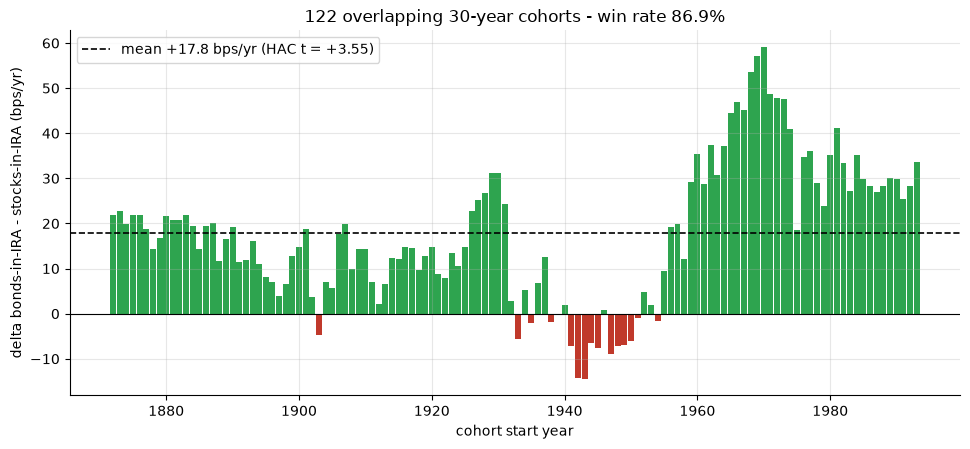

delta_bs: mean +17.78 bps/yr  HAC t(lag 29) +3.55  win 86.9%
delta_bp: mean +8.55 bps/yr  HAC t(lag 29) +3.11


In [2]:
if HAVE_REAL:
    s = st.summarize_cohorts(TAB)
    x = TAB.index.to_numpy(); y = TAB['delta_bs'].to_numpy()
    mu, t_bs, win = s['mean_delta_bs'], s['t_bs'], s['win_bs']
    mu_bp, t_bp = s['mean_delta_bp'], s['t_bp']
else:
    rng = np.random.default_rng(600)
    x = np.arange(1872, 1994); y = rng.normal(R['delta_bs'], 15, len(x))
    mu, t_bs, win, mu_bp, t_bp = R['delta_bs'], R['t_bs'], R['win_bs'], R['delta_bp'], R['t_bp']
fig, ax = plt.subplots(figsize=(9.8, 4.6))
ax.bar(x, y, color=[GREEN if v >= 0 else RED for v in y], width=.9)
ax.axhline(mu, c='k', ls='--', lw=1.2, label=f'mean {mu:+.1f} bps/yr (HAC t = {t_bs:+.2f})')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('cohort start year'); ax.set_ylabel('delta bonds-in-IRA - stocks-in-IRA (bps/yr)')
ax.set_title(f'{len(x)} overlapping 30-year cohorts - win rate {win:.1f}%')
ax.legend(); plt.tight_layout(); plt.show()
print(f'delta_bs: mean {mu:+.2f} bps/yr  HAC t(lag 29) {t_bs:+.2f}  win {win:.1f}%')
print(f'delta_bp: mean {mu_bp:+.2f} bps/yr  HAC t(lag 29) {t_bp:+.2f}')

> 💡 In plain words: the rule pays **+17.78 bps/yr** on average and the overlap-corrected *t* is **+3.55** — the desk's *t* ≥ 2 bar is cleared on the real tape, not by the literature. Even against the pro-rata default (closer race, since pro-rata already shelters 60% of the bonds) it's **+8.55 bps/yr** at *t* = **+3.11**. The negative cohorts (13%) cluster where equity crashes made the taxable-stock policy's *loss carryforwards* valuable.

### 4b · The benefit scales with the yield level

The mechanism is annually-taxed coupon income sheltered by the IRA — so the delta should be (nearly mechanically) increasing in the cohort's average locked coupon.

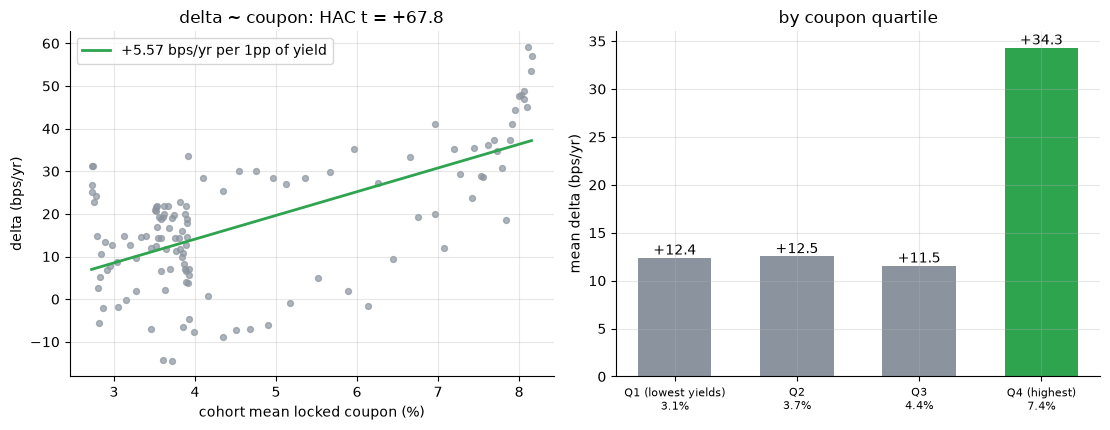

quartile deltas: {'Q1 (lowest yields)': np.float64(12.38), 'Q2': np.float64(12.53), 'Q3': np.float64(11.55), 'Q4 (highest)': np.float64(34.3)} | slope +5.57 t +67.8


In [3]:
if HAVE_REAL:
    s = st.summarize_cohorts(TAB)
    cx = 100 * TAB['mean_cpn'].to_numpy(); cy = TAB['delta_bs'].to_numpy()
    slope, t_slope = s['slope_bps_per_pp'], s['t_slope']
    q = st.yield_quartiles(TAB)
    ql = list(q.index); qc = q['mean_cpn_pct'].to_numpy(); qd = q['mean_delta_bs'].to_numpy()
else:
    slope, t_slope = R['slope'], R['t_slope']
    ql = [r[0] for r in R['quart']]; qc = np.array([r[1] for r in R['quart']])
    qd = np.array([r[2] for r in R['quart']])
    rng = np.random.default_rng(1)
    cx = rng.uniform(2.5, 9, 122); cy = slope * cx + rng.normal(0, 6, 122)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.scatter(cx, cy, s=18, color=GREY, alpha=.7)
xs = np.linspace(cx.min(), cx.max(), 50)
b0 = cy.mean() - slope * cx.mean()
a1.plot(xs, b0 + slope * xs, c=GREEN, lw=2, label=f'{slope:+.2f} bps/yr per 1pp of yield')
a1.set_xlabel('cohort mean locked coupon (%)'); a1.set_ylabel('delta (bps/yr)')
a1.set_title(f'delta ~ coupon: HAC t = {t_slope:+.1f}'); a1.legend()
a2.bar(range(4), qd, color=[GREY, GREY, GREY, GREEN], width=.6)
a2.set_xticks(range(4)); a2.set_xticklabels([f'{l}\n{c:.1f}%' for l, c in zip(ql, qc)], fontsize=8)
for i, v in enumerate(qd): a2.annotate(f'{v:+.1f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('mean delta (bps/yr)'); a2.set_title('by coupon quartile')
plt.tight_layout(); plt.show()
print('quartile deltas:', dict(zip(ql, np.round(qd, 2))), f'| slope {slope:+.2f} t {t_slope:+.1f}')

> 💡 In plain words: each extra percentage point of bond yield adds about **+5.6 bps/yr** to the prize (HAC *t* = +67.8 — near-mechanical, exactly as the arithmetic predicts). The 1970s-80s cohorts (Q4, 7.4% average yields) banked **+34.3 bps/yr**; the low-yield quartile still gets **+12.4**. Low rates shrink the lunch — they don't cancel it.

### 4c · The tax-rate grid

The engine of the rule is the **wedge** between the ordinary rate (what coupons pay) and the LTCG rate (what equity pays). Re-run all 122 cohorts per (ordinary, LTCG) cell.

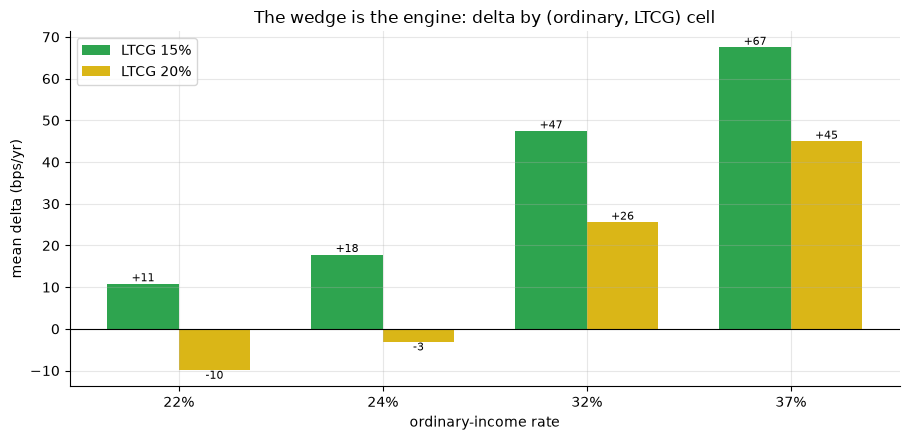

ordinary 22% / LTCG 15%:  +10.77 bps/yr  t +2.26  win 77%
ordinary 22% / LTCG 20%:   -9.95 bps/yr  t -1.84  win 31%
ordinary 24% / LTCG 15%:  +17.78 bps/yr  t +3.55  win 87%
ordinary 24% / LTCG 20%:   -3.16 bps/yr  t -0.57  win 47%
ordinary 32% / LTCG 15%:  +47.43 bps/yr  t +7.68  win 100%
ordinary 32% / LTCG 20%:  +25.54 bps/yr  t +4.09  win 91%
ordinary 37% / LTCG 15%:  +67.47 bps/yr  t +9.62  win 100%
ordinary 37% / LTCG 20%:  +44.96 bps/yr  t +6.56  win 100%


In [4]:
if HAVE_REAL:
    g = st.rate_grid(COMP)
    grid = [(int(100*r.ordinary), int(100*r.ltcg), r.mean_delta_bs, r.t_bs, r.win_pct)
            for r in g.itertuples()]
else:
    grid = R['grid']
ords = sorted(set(r[0] for r in grid))
fig, ax = plt.subplots(figsize=(9.2, 4.5))
w = .35
for k, lt in enumerate((15, 20)):
    vals = [next(r[2] for r in grid if r[0] == o and r[1] == lt) for o in ords]
    ax.bar(np.arange(len(ords)) + (k - .5) * w, vals, w, color=[GREEN, AMBER][k], label=f'LTCG {lt}%')
    for i, v in enumerate(vals): ax.annotate(f'{v:+.0f}', (i + (k - .5) * w, v), ha='center',
                                             va='bottom' if v >= 0 else 'top', fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(range(len(ords))); ax.set_xticklabels([f'{o}%' for o in ords])
ax.set_xlabel('ordinary-income rate'); ax.set_ylabel('mean delta (bps/yr)')
ax.set_title('The wedge is the engine: delta by (ordinary, LTCG) cell')
ax.legend(); plt.tight_layout(); plt.show()
for r in grid: print(f'ordinary {r[0]}% / LTCG {r[1]}%: {r[2]:+7.2f} bps/yr  t {r[3]:+.2f}  win {r[4]:.0f}%')

> 💡 In plain words: every **realistic** 2026 US pair (22/15, 24/15, 32/15, 37/20 — the 20% LTCG rate only exists inside the top ordinary brackets) is **positive**, from **+10.8** to **+67.5 bps/yr**. The negative cells (22/20 = -9.9, 24/20 = -3.2) are hypothetical narrow-wedge households — instructive, because they show the delta is literally the ordinary-vs-LTCG wedge priced through the account boundary, but they are not real US bracket combinations.

### 4d · The third axis — the turnover flip

Shoven-Sialm's reversal: if the equity sleeve itself is tax-inefficient (high turnover), the preference should reverse. Sweep equity turnover 0 → 100% over all cohorts.

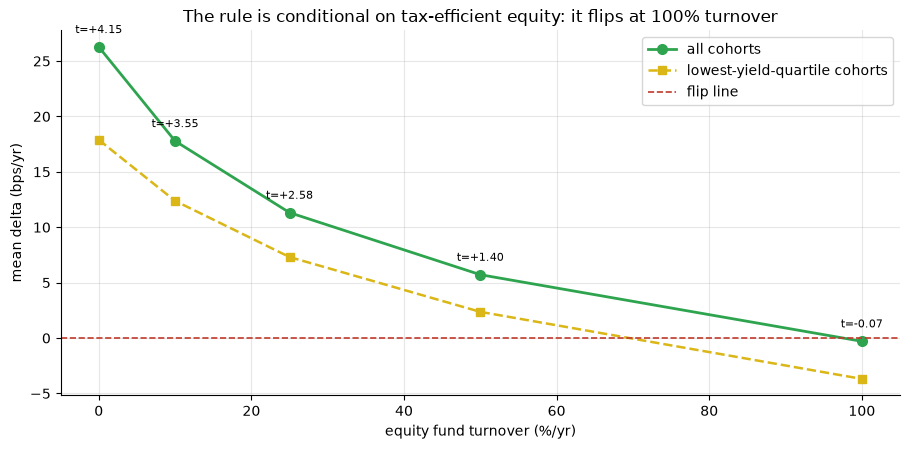

turnover   0%:  +26.27 bps/yr  t +4.15  low-yield-Q +17.89
turnover  10%:  +17.78 bps/yr  t +3.55  low-yield-Q +12.38
turnover  25%:  +11.32 bps/yr  t +2.58  low-yield-Q +7.31
turnover  50%:   +5.72 bps/yr  t +1.40  low-yield-Q +2.36
turnover 100%:   -0.29 bps/yr  t -0.07  low-yield-Q -3.69


In [5]:
if HAVE_REAL:
    tf = st.turnover_flip(COMP)
    xs = (100 * tf['turnover']).to_numpy(); ys = tf['mean_delta_bs'].to_numpy()
    lo = tf['lowq_delta_bs'].to_numpy(); ts = tf['t_bs'].to_numpy()
else:
    xs = np.array([f[0] for f in R['flip']]); ys = np.array([f[1] for f in R['flip']])
    ts = np.array([f[2] for f in R['flip']]); lo = np.array([f[4] for f in R['flip']])
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(xs, ys, 'o-', color=GREEN, lw=2, ms=7, label='all cohorts')
ax.plot(xs, lo, 's--', color=AMBER, lw=1.8, ms=6, label='lowest-yield-quartile cohorts')
ax.axhline(0, c=RED, ls='--', lw=1.2, label='flip line')
for x_, y_, t_ in zip(xs, ys, ts): ax.annotate(f't={t_:+.2f}', (x_, y_), textcoords='offset points',
                                               xytext=(0, 10), ha='center', fontsize=8)
ax.set_xlabel('equity fund turnover (%/yr)'); ax.set_ylabel('mean delta (bps/yr)')
ax.set_title('The rule is conditional on tax-efficient equity: it flips at 100% turnover')
ax.legend(); plt.tight_layout(); plt.show()
for x_, y_, t_, l_ in zip(xs, ys, ts, lo): print(f'turnover {x_:3.0f}%: {y_:+7.2f} bps/yr  t {t_:+.2f}  low-yield-Q {l_:+.2f}')

> 💡 In plain words: **it flips.** At 100% turnover the mean delta is **-0.29 bps/yr** (*t* = -0.07) and **-3.69** in low-yield cohorts; at ≥50% turnover the benefit is already statistically zero (*t* = +1.40). The claim's fine print — "stocks are the tax-efficient asset" — is doing real work. Index-fund households (0-10% turnover) keep the whole lunch; active-fund households in low-rate decades lose it. **CONFIRMED** on the third axis.

### 4e · The modern low-rate cohort — SPY + IEF, real fund distributions

The "it no longer matters at today's yields" objection, tested on actual fund cash flows 2003-2025 (IEF distribution yield ≈ 2.9%).

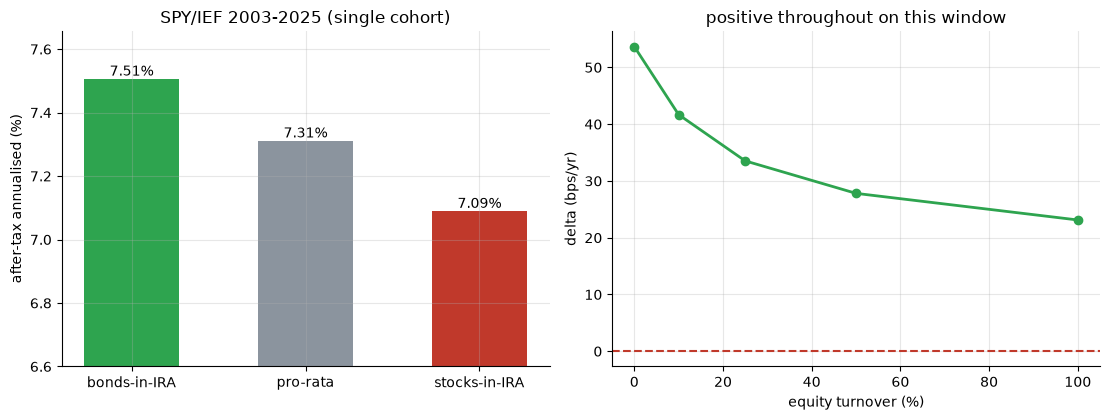

modern delta_bs +41.68 bps/yr | vs pro-rata +19.49 | sweep [(0, 53.7), (10, 41.7), (25, 33.5), (50, 27.8), (100, 23.1)]


In [6]:
if HAVE_MODERN:
    px, dv = data.load_modern()
    mc = data.modern_components(px, dv)
    r = st.single_cohort(mc)
    vals = [r['ann_bonds_ira'], r['ann_pro_rata'], r['ann_stocks_ira']]
    sweep = [(tv, st.single_cohort(mc, turnover=tv)['delta_bs']) for tv in (0., .10, .25, .50, 1.0)]
    d_bs, d_bp = r['delta_bs'], r['delta_bp']
else:
    m = R['modern']; vals = [m['ann_bonds'], m['ann_prorata'], m['ann_stocks']]
    sweep = [(t / 100, d) for t, d in m['sweep']]; d_bs, d_bp = m['delta_bs'], m['delta_bp']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.bar(['bonds-in-IRA', 'pro-rata', 'stocks-in-IRA'], vals, color=[GREEN, GREY, RED], width=.55)
for i, v in enumerate(vals): a1.annotate(f'{v:.2f}%', (i, v), ha='center', va='bottom')
a1.set_ylabel('after-tax annualised (%)'); a1.set_ylim(6.6, max(vals) + .15)
a1.set_title('SPY/IEF 2003-2025 (single cohort)')
a2.plot([100 * t for t, _ in sweep], [d for _, d in sweep], 'o-', color=GREEN, lw=2)
a2.axhline(0, c=RED, ls='--')
a2.set_xlabel('equity turnover (%)'); a2.set_ylabel('delta (bps/yr)')
a2.set_title('positive throughout on this window')
plt.tight_layout(); plt.show()
print(f'modern delta_bs {d_bs:+.2f} bps/yr | vs pro-rata {d_bp:+.2f} | sweep', [(int(100*t), round(d, 1)) for t, d in sweep])

> 💡 In plain words: even in the lowest-yield quarter-century on record the rule paid **+41.7 bps/yr** (single cohort — no *t*; the long tape carries the inference). It stays positive at every turnover here because 2003-2025 equity gains were enormous (deferral was worth a lot) while the bond price leg was small. One window, one draw — but the objection "low rates killed asset location" is not what this tape shows.

### 4f · Faithful-engine control — the zero-tax null and the planted coupon

Two things the simulator must prove. **The null:** with zero tax rates the account boundary is meaningless — every policy must return *exactly* the same wealth (delta = 0.000, all seeds). **The knob:** the benefit is sheltered coupon income, so a planted coupon must scale the measured delta monotonically. Averaged over 20 seeds.

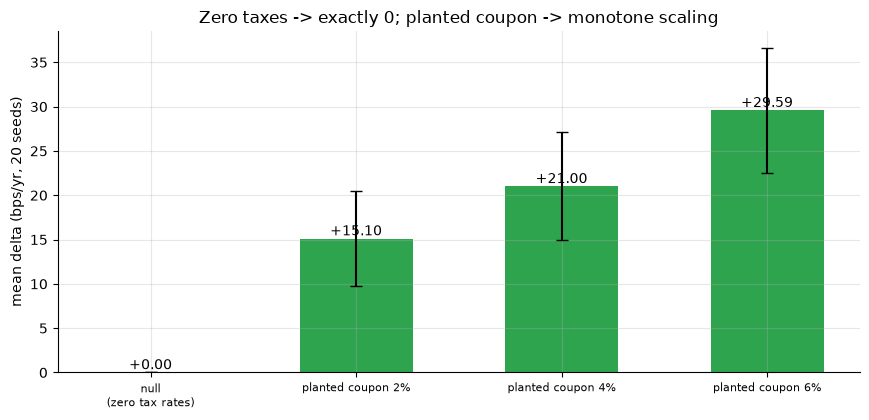

null (zero tax rates)   :   +0.000 bps/yr (sd 0.000)
planted coupon 2%       :  +15.105 bps/yr (sd 5.366)
planted coupon 4%       :  +21.000 bps/yr (sd 6.097)
planted coupon 6%       :  +29.585 bps/yr (sd 7.079)


In [7]:
syn = st.synthetic_scaling()
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = syn['label'].tolist(); vals = syn['mean_delta_bs'].to_numpy(); sds = syn['sd_delta_bs'].to_numpy()
colors = [GREY] + [GREEN] * (len(vals) - 1)
ax.bar(range(len(vals)), vals, yerr=sds, capsize=4, color=colors, width=.55)
for i, v in enumerate(vals): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom')
ax.set_xticks(range(len(vals))); ax.set_xticklabels([l.replace(' (', '\n(') for l in labels], fontsize=8)
ax.set_ylabel('mean delta (bps/yr, 20 seeds)')
ax.set_title('Zero taxes -> exactly 0; planted coupon -> monotone scaling')
plt.tight_layout(); plt.show()
for l, v, s_ in zip(labels, vals, sds): print(f'{l:<24s}: {v:+8.3f} bps/yr (sd {s_:.3f})')

> 💡 In plain words: the simulator returns **exactly 0.000** when taxes are zero (it cannot invent a location benefit) and the planted coupon knob scales the delta monotonically (15.1 → 21.0 → 29.6 bps/yr). *(A machinery proof only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `REAL` (traditional IRA)** — mean delta **+17.78 bps/yr** over **122** overlapping 30-year cohorts, **HAC *t* (lag 29) = +3.55**, win rate 86.9%; vs pro-rata **+8.55 bps/yr** (*t* = +3.11); compounds to **+5.2%** terminal wealth. Positive at every realistic US bracket pair. Genuine and reproducing — honestly scoped to the **tax-deferred** account Dammon-Spatt-Zhang model.
- **Tradability `FRAGILE`** — relocating is free (differential cost **+0.013 bps/yr**), but the free lunch is **conditional on a traditional IRA**. Re-run the identical 122 cohorts with a **Roth** terminal settlement (withdrawal untaxed) and the rule inverts: bonds-in-Roth **−28.57 bps/yr**, **HAC *t* = −3.15**, win 10.7%, deepening to −43.9 bps/yr at 100% turnover. A Roth retail household following "bonds in the IRA" loses tens of bps a year — so the sign is *not* universal.
- **Does it flip? `CONFIRMED` (two axes)** — (1) at 100% equity turnover the delta crosses zero (**-0.29 bps/yr**, *t* = -0.07; **-3.69** in low-yield cohorts) — Shoven-Sialm's reversal on the tape; (2) Roth-vs-traditional inverts it outright (**−28.6 bps/yr**, *t* = −3.15) — the bigger, more common flip.

## 6 · Going further

- **Roth doesn't just change the algebra — it flips the sign.** A Roth IRA has no terminal ordinary-rate haircut, so the asset with the *highest expected return* (equity) should sit inside it. Setting the terminal IRA factor to `1.0` and re-running the identical 122 cohorts, bonds-in-Roth **loses** to stocks-in-Roth by **−28.6 bps/yr** (HAC *t* = −3.15, win 10.7%) — a full reversal, not a partial one. This is why Tradability is `FRAGILE`: the rule's sign depends on an account-type assumption the headline never stated.
- **Municipal bonds are the escape hatch.** A high-bracket household with no IRA room can swap taxable bonds for munis — which is why the observed cross-section (Bergstresser-Poterba) is messier than the rule.
- **The wedge generalises.** REITs, TIPS, high-yield — anything paying ordinary income slots into the same arithmetic: shelter the asset with the highest *annually-taxed yield × wedge* product.
- **Siblings.** [599 — Tax-Loss-Harvesting](../../599-tax-loss-harvesting/) graded the other "free tax alpha" claim **Fragile** (front-loaded, path-dependent); this one also grades **Fragile** on tradability — the signal is real and needs no losses, timing or turnover, but its *sign* is conditional on a traditional (not Roth) IRA.

*The reproducible core is offline and deterministic; methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*